In [27]:
#importing required libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


Underdamped Data Preview:
   time  position  velocity  acceleration        KE         PE    Total_E  \
0   0.0  1.000000  0.000000    -20.000000  0.000000  10.000000  10.000000   
1   0.1  0.904917 -1.839917    -16.258417  1.692647   8.188742   9.881388   
2   0.2  0.649610 -3.160678     -9.831512  4.994942   4.219925   9.214867   
3   0.3  0.297073 -3.764608     -2.176857  7.086138   0.882525   7.968663   
4   0.4 -0.077502 -3.606919      5.156953  6.504931   0.060065   6.564996   

    F_spring  F_damping    F_total  analytical     error  
0 -20.000000  -0.000000 -20.000000    1.000000  0.000000  
1 -18.098333   1.839917 -16.258417    0.904843  0.000074  
2 -12.992190   3.160678  -9.831512    0.649377  0.000232  
3  -5.941466   3.764608  -2.176857    0.296675  0.000398  
4   1.550034   3.606919   5.156953   -0.077992  0.000491  
Underdamped Max Error: 0.0011147281163825257


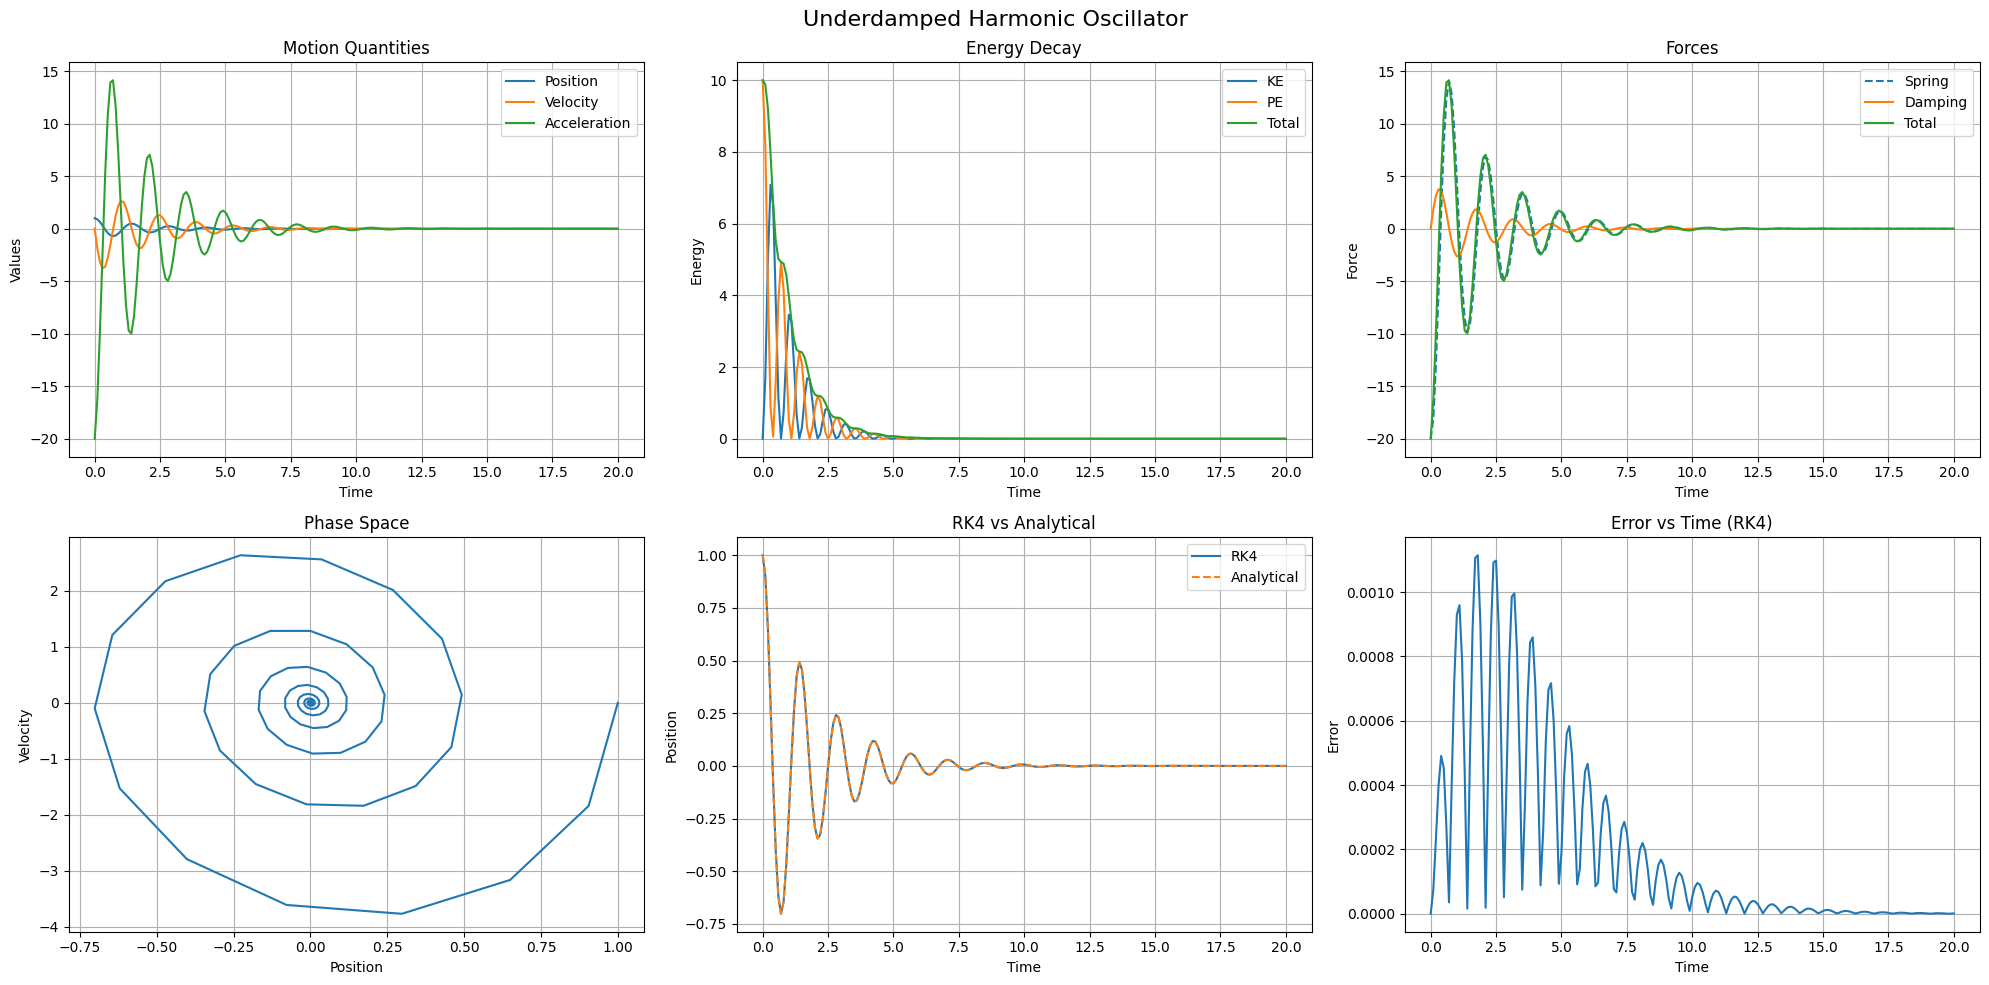


Critically Damped Data Preview:
   time  position  velocity  acceleration        KE         PE    Total_E  \
0   0.0  1.000000  0.000000    -20.000000  0.000000  10.000000  10.000000   
1   0.1  0.924814 -1.275759     -7.085553  0.813780   8.552814   9.366594   
2   0.2  0.773903 -1.631812     -0.882693  1.331406   5.989264   7.320670   
3   0.3  0.611627 -1.565429      1.769080  1.225283   3.740875   4.966158   
4   0.4  0.465786 -1.334885      2.623855  0.890959   2.169565   3.060523   

    F_spring  F_damping    F_total  analytical     error  
0 -20.000000  -0.000000 -20.000000    1.000000  0.000000  
1 -18.496285  11.410732  -7.085553    0.925359  0.000545  
2 -15.478068  14.595374  -0.882693    0.774521  0.000617  
3 -12.232539  14.001619   1.769080    0.612143  0.000516  
4  -9.315717  11.939572   2.623855    0.466161  0.000375  
Critically Damped Max Error: 0.0006174892053751879


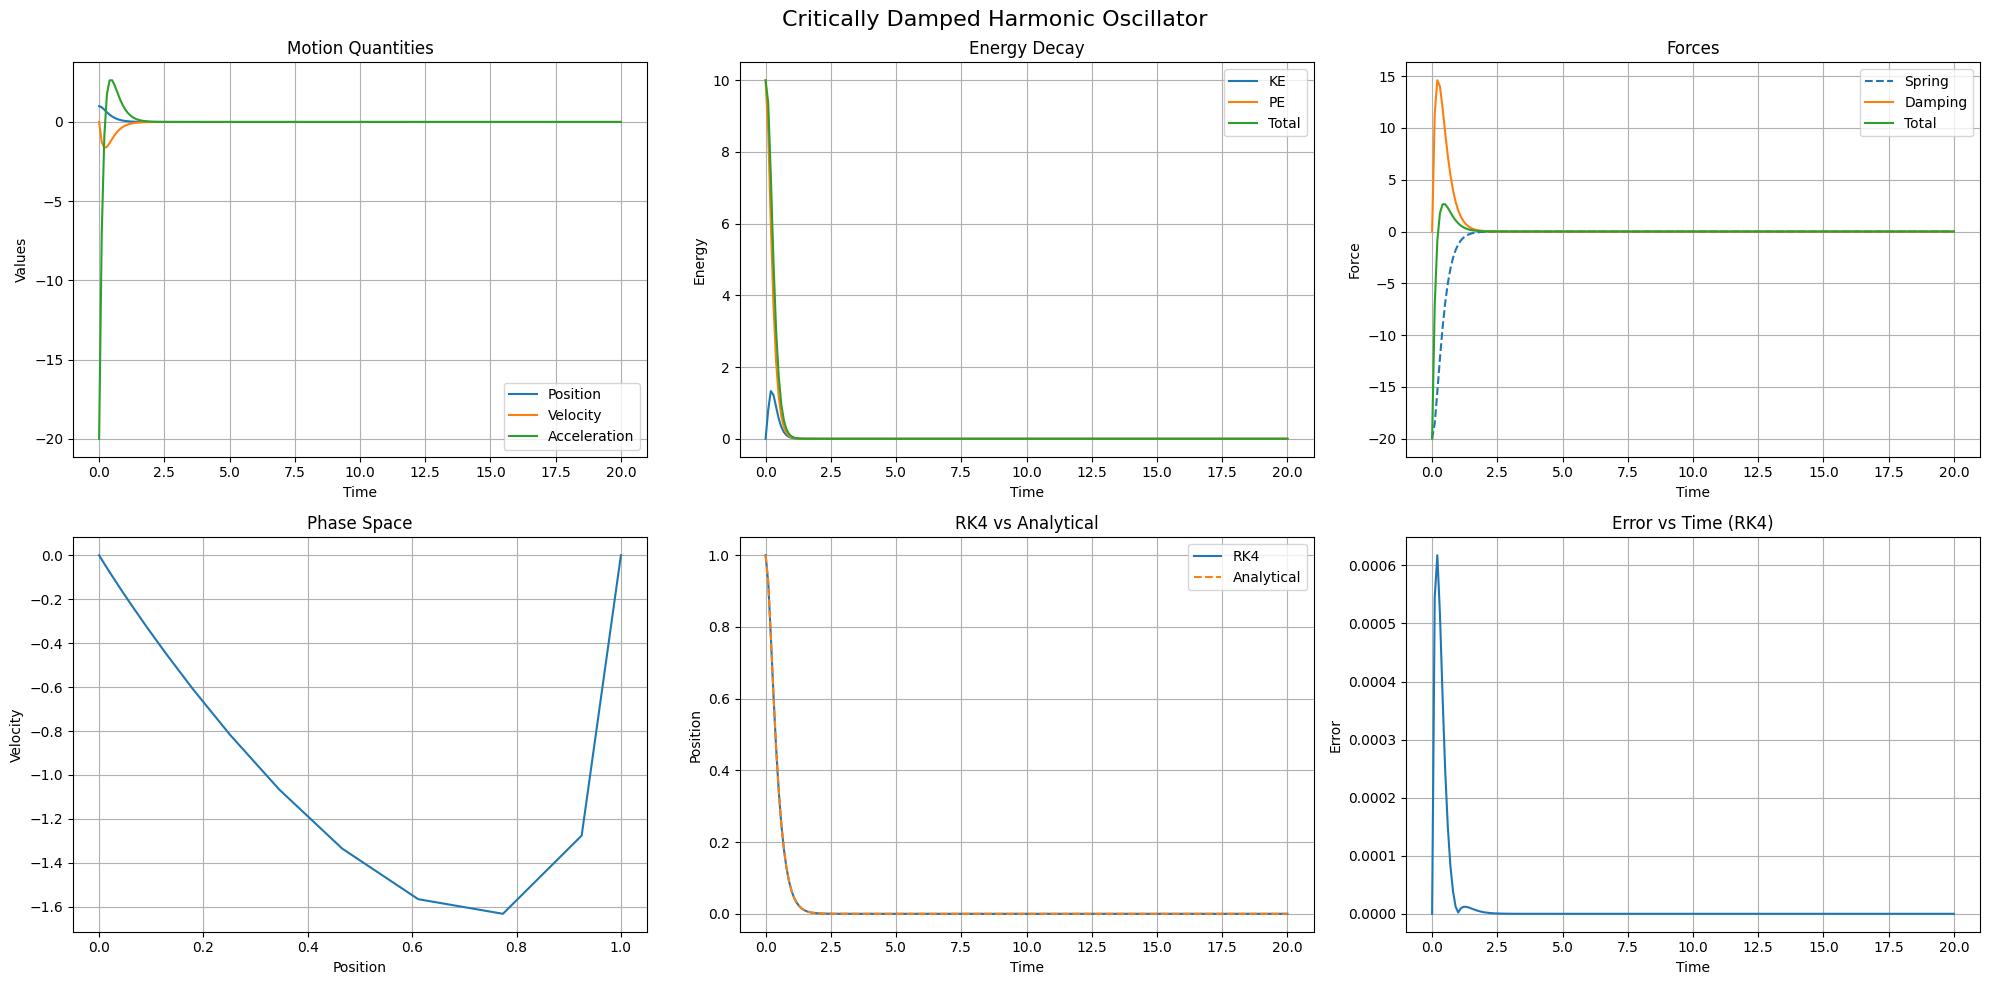


Overdamped Data Preview:
   time  position  velocity  acceleration        KE         PE    Total_E  \
0   0.0  1.000000  0.000000    -20.000000  0.000000  10.000000  10.000000   
1   0.1  0.929667 -1.109333     -5.281333  0.615310   8.642801   9.258111   
2   0.2  0.802749 -1.324248     -0.164004  0.876817   6.444061   7.320878   
3   0.3  0.672837 -1.240206      1.425725  0.769056   4.527102   5.296158   
4   0.4  0.556724 -1.073898      1.752288  0.576629   3.099421   3.676050   

    F_spring  F_damping    F_total  analytical     error  
0 -20.000000  -0.000000 -20.000000    1.000000  0.000000  
1 -18.593333  13.312000  -5.281333    0.931444  0.001777  
2 -16.054982  15.890978  -0.164004    0.804066  0.001317  
3 -13.456749  14.882473   1.425725    0.673568  0.000730  
4 -11.134489  12.886777   1.752288    0.557082  0.000358  
Overdamped Max Error: 0.0017769143879501348


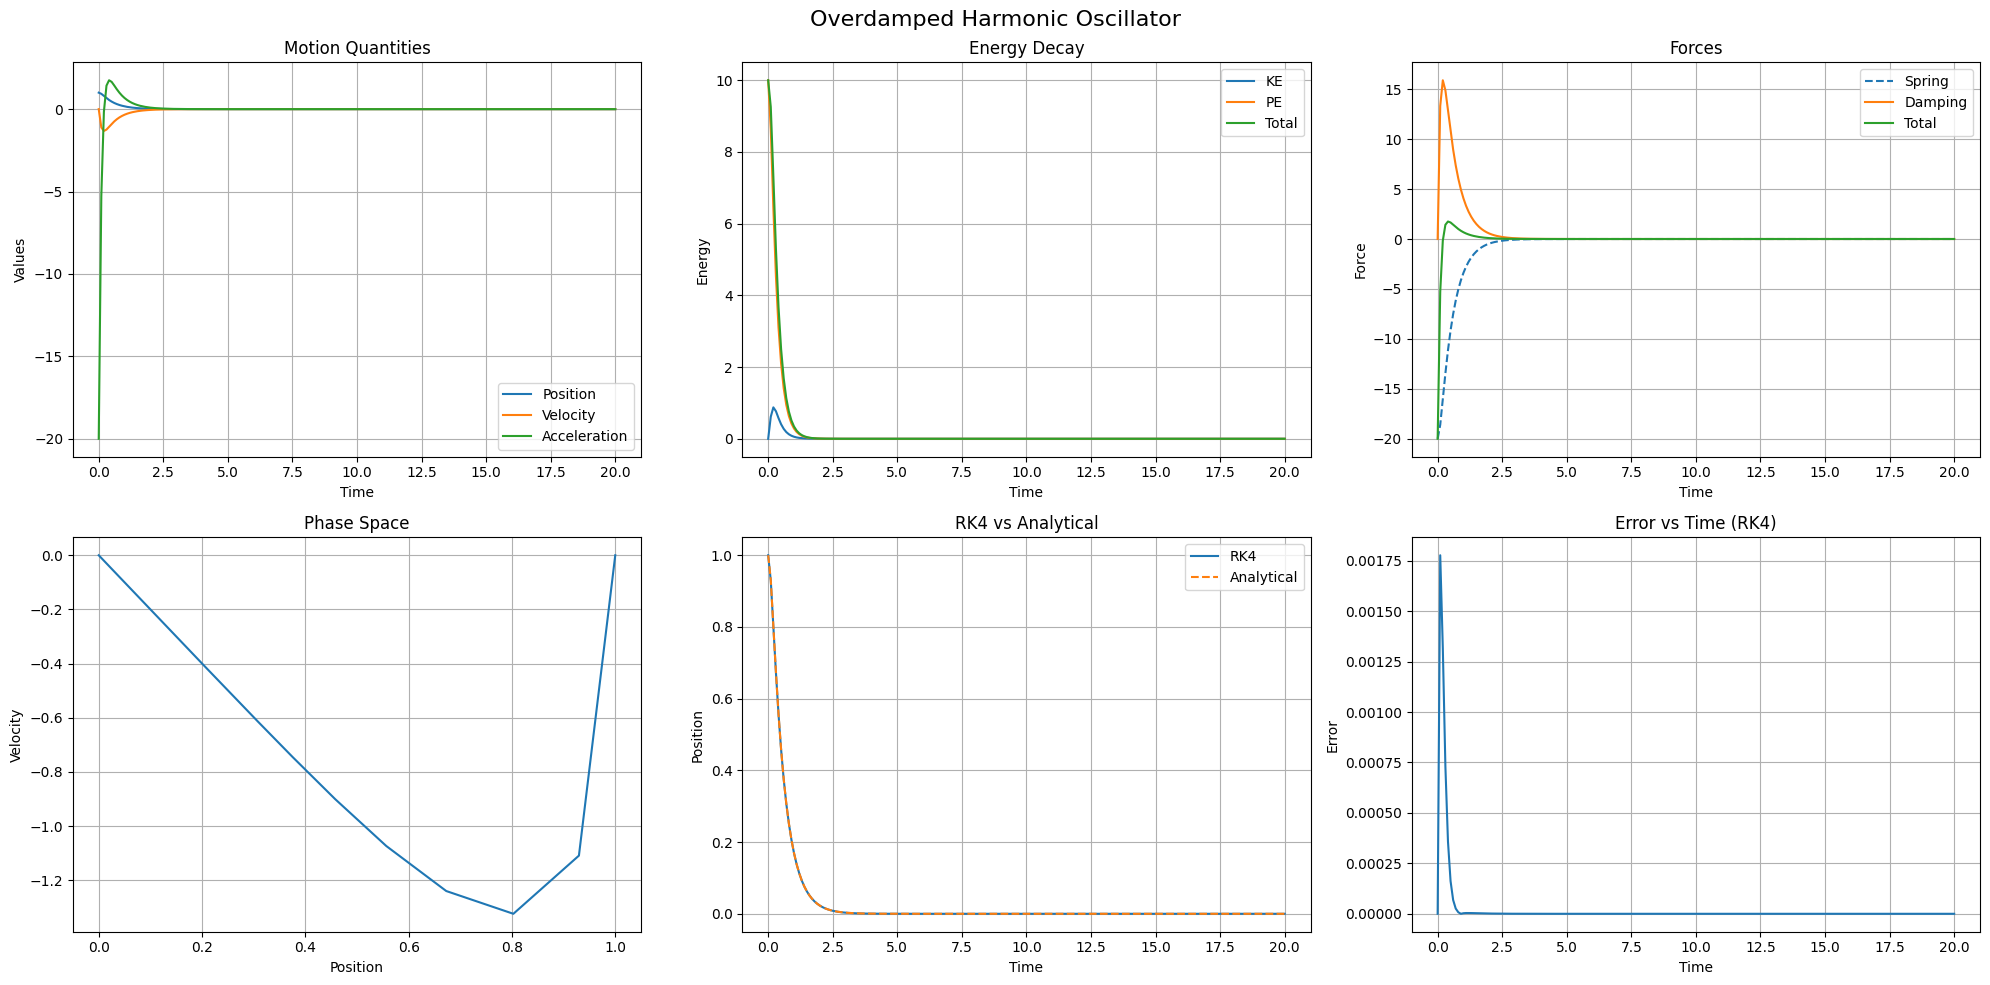

In [28]:
#Defining RK4 function
def rk4(f, x0, y0, h, n):
    x = x0
    y = np.array(y0)

    x_values = [x0]
    y_values = [y0]

    for i in range(n):
        k1 = f(x, y)
        k2 = f(x + h/2, y + (h/2)*k1)
        k3 = f(x + h/2, y + (h/2)*k2)
        k4 = f(x + h, y + h*k3)

        y = y + (h/6)*(k1 + 2*k2 + 2*k3 + k4)
        x = x + h

        x_values.append(x)
        y_values.append(y.copy())

    return np.array(x_values), np.array(y_values)

#parameters
m = 1
k = 20
y0 = [1.0, 0.0]
t0 = 0.0
h  = 0.1
n  = 200

#Column labels
columns = [
    "time", "position", "velocity", "acceleration",
    "KE", "PE", "Total_E",
    "F_spring", "F_damping", "F_total",
    "analytical", "error"
]

#Storage dictionary
results = {}

#Damping cases
cases = {
    "Underdamped": 1,
    "Critically Damped": 2*np.sqrt(m*k),
    "Overdamped": 12
}

#main loop for the calculation and graphs of three conditions underdamped, critically damped and overdamped
for case_name, c in cases.items():
    
    #ODE function
    def f(t, y):
        y1, y2 = y
        dy1 = y2
        dy2 = -(c/m)*y2 - (k/m)*y1
        return np.array([dy1, dy2])

    t, y = rk4(f, t0, y0, h, n)

    position = y[:, 0]
    velocity = y[:, 1]
    acceleration = -(c/m)*velocity - (k/m)*position

    KE = 0.5 * m * velocity**2
    PE = 0.5 * k * position**2
    Total_E = KE + PE

    F_damping = -c * velocity
    F_spring = -k * position
    F_total = m * acceleration

    #Analytical solutions
    if case_name == "Underdamped":
        omega_d = np.sqrt(4*m*k - c**2)/(2*m)
        def x_analytical(t):
            return np.exp(-c*t/(2*m)) * (
                np.cos(omega_d*t) + (c/(2*m*omega_d))*np.sin(omega_d*t)
            )

    elif case_name == "Critically Damped":
        gamma = c/(2*m)
        def x_analytical(t):
            return (1 + gamma*t) * np.exp(-gamma*t)

    else: #overdamped
        disc = np.sqrt(c**2 - 4*m*k)
        r1 = (-c + disc)/(2*m)
        r2 = (-c - disc)/(2*m)

        A = r2/(r2 - r1)
        B = -r1/(r2 - r1)

        def x_analytical(t):
            return A*np.exp(r1*t) + B*np.exp(r2*t)

    x_exact = x_analytical(t)
    error = np.abs(position - x_exact)

    #store matrix
    data_matrix = np.column_stack([
        t, position, velocity, acceleration,
        KE, PE, Total_E,
        F_spring, F_damping, F_total,
        x_exact, error
    ])

    results[case_name] = data_matrix

    #save CSV
    df = pd.DataFrame(data_matrix, columns=columns)
    df.to_csv(f"{case_name}_matrix.csv", index=False)

    print(f"\n{case_name} Data Preview:")
    print(df.head())
    print(f"{case_name} Max Error:", np.max(error))

    #plotting
    fig, ax = plt.subplots(2, 3, figsize=(20, 10))
    fig.suptitle(f"{case_name} Harmonic Oscillator", fontsize=16)

    #Motion
    ax[0,0].plot(t, position, label="Position")
    ax[0,0].plot(t, velocity, label="Velocity")
    ax[0,0].plot(t, acceleration, label="Acceleration")
    ax[0,0].set_xlabel("Time")
    ax[0,0].set_ylabel("Values")
    ax[0,0].set_title("Motion Quantities")
    ax[0,0].legend()
    ax[0,0].grid()

    #Energy
    ax[0,1].plot(t, KE, label="KE")
    ax[0,1].plot(t, PE, label="PE")
    ax[0,1].plot(t, Total_E, label="Total")
    ax[0,1].set_xlabel("Time")
    ax[0,1].set_ylabel("Energy")
    ax[0,1].set_title("Energy Decay")
    ax[0,1].legend()
    ax[0,1].grid()

    #Forces
    ax[0,2].plot(t, F_spring, '--', label="Spring")
    ax[0,2].plot(t, F_damping, label="Damping")
    ax[0,2].plot(t, F_total, label="Total")
    ax[0,2].set_xlabel("Time")
    ax[0,2].set_ylabel("Force")
    ax[0,2].set_title("Forces")
    ax[0,2].legend() 
    ax[0,2].grid()

    #Phase space
    ax[1,0].plot(position, velocity)
    ax[1,0].set_xlabel("Position")
    ax[1,0].set_ylabel("Velocity")
    ax[1,0].set_title("Phase Space")
    ax[1,0].grid()

    #RK4 vs Analytical
    ax[1,1].plot(t, position, label="RK4")
    ax[1,1].plot(t, x_exact, '--', label="Analytical")
    ax[1,1].set_xlabel("Time")
    ax[1,1].set_ylabel("Position")
    ax[1,1].set_title("RK4 vs Analytical")
    ax[1,1].legend()
    ax[1,1].grid()

    #Error
    ax[1,2].plot(t, error)
    ax[1,2].set_xlabel("Time")
    ax[1,2].set_ylabel("Error")
    ax[1,2].set_title("Error vs Time (RK4)")
    ax[1,2].grid()

    plt.tight_layout()
    plt.show()

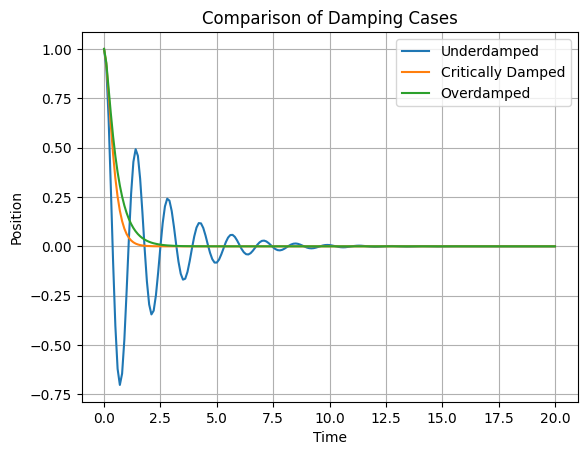

In [29]:
#Combined position plot
plt.figure()
for case in results:
    plt.plot(results[case][:,0], results[case][:,1], label=case)

plt.xlabel("Time")
plt.ylabel("Position")
plt.title("Comparison of Damping Cases")
plt.legend()
plt.grid()
plt.show()

Underdamped Convergence Order: 4.024624517671918
Critically Damped Convergence Order: 4.396909000368389
Overdamped Convergence Order: 4.5751308133835655


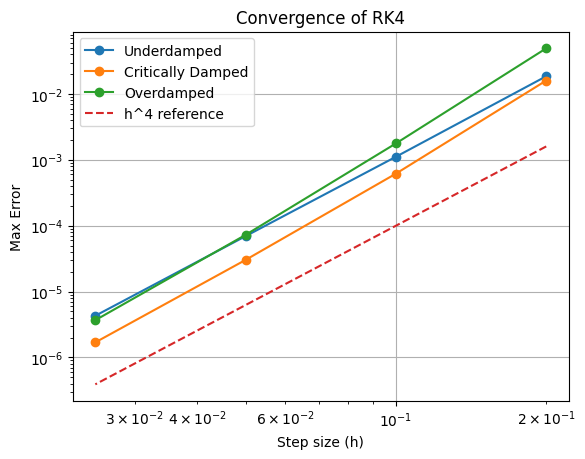

In [30]:
#Convergence test
h_values = [0.2, 0.1, 0.05, 0.025]

plt.figure()

for case_name, c in cases.items():

    errors = []

    #ODE function
    def f(t, y):
        y1, y2 = y
        dy1 = y2
        dy2 = -(c/m)*y2 - (k/m)*y1
        return np.array([dy1, dy2])

    if case_name == "Underdamped":
        omega_d = np.sqrt(4*m*k - c**2)/(2*m)
        def x_analytical(t):
            return np.exp(-c*t/(2*m)) * (
                np.cos(omega_d*t) + (c/(2*m*omega_d))*np.sin(omega_d*t)
            )

    elif case_name == "Critically Damped":
        gamma = c/(2*m)
        def x_analytical(t):
            return (1 + gamma*t) * np.exp(-gamma*t)

    else:
        disc = np.sqrt(c**2 - 4*m*k)
        r1 = (-c + disc)/(2*m)
        r2 = (-c - disc)/(2*m)

        A = r2/(r2 - r1)
        B = -r1/(r2 - r1)

        def x_analytical(t):
            return A*np.exp(r1*t) + B*np.exp(r2*t)

    for h_test in h_values:
        n_test = int(20 / h_test)

        t_test, y_test = rk4(f, t0, y0, h_test, n_test)
        pos_test = y_test[:, 0]

        x_exact_test = x_analytical(t_test)

        err = np.max(np.abs(pos_test - x_exact_test))
        errors.append(err)

    #slope calculation
    log_h = np.log(h_values)
    log_e = np.log(errors)
    slope = np.polyfit(log_h, log_e, 1)[0]

    print(f"{case_name} Convergence Order:", slope)

    plt.loglog(h_values, errors, marker='o', label=case_name)

#reference slope
ref = [h**4 for h in h_values]
plt.loglog(h_values, ref, '--', label='h^4 reference')

plt.xlabel("Step size (h)")
plt.ylabel("Max Error")
plt.title("Convergence of RK4")
plt.legend()
plt.grid()
plt.show()